Training Complete!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step


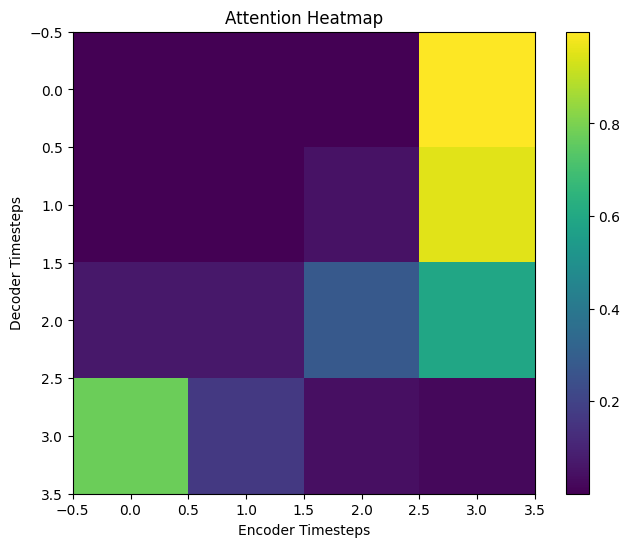

In [2]:
# ==========================================
# Lab 6: Seq2Seq with Attention + Heatmap
# ==========================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ============================
# 1️⃣ Sample Dummy Data
# ============================

# Toy dataset (integer sequences)
encoder_input_data = [
    [1, 2, 3, 4],
    [2, 3, 4, 0],
    [3, 4, 0, 0]
]

decoder_input_data = [
    [0, 5, 6, 7],
    [0, 6, 7, 8],
    [0, 7, 8, 9]
]

decoder_output_data = [
    [5, 6, 7, 8],
    [6, 7, 8, 9],
    [7, 8, 9, 0]
]

encoder_input_data = np.array(encoder_input_data)
decoder_input_data = np.array(decoder_input_data)
decoder_output_data = np.array(decoder_output_data)

vocab_size = 15
embedding_dim = 64
units = 64

# ============================
# 2️⃣ Encoder
# ============================

encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(vocab_size, embedding_dim)(encoder_inputs)

encoder_lstm = LSTM(units, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# ============================
# 3️⃣ Decoder
# ============================

decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(vocab_size, embedding_dim)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

# ============================
# 4️⃣ Attention Layer
# ============================

attention = tf.keras.layers.Attention()
attention_output = attention([decoder_outputs, encoder_outputs])

# Save attention weights model
attention_model = Model(
    [encoder_inputs, decoder_inputs],
    attention([decoder_outputs, encoder_outputs], return_attention_scores=True)[1]
)

# Concatenate
concat = tf.keras.layers.Concatenate(axis=-1)([decoder_outputs, attention_output])

decoder_dense = Dense(vocab_size, activation='softmax')
decoder_outputs = decoder_dense(concat)

# ============================
# 5️⃣ Final Model
# ============================

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ============================
# 6️⃣ Train Model
# ============================

model.fit(
    [encoder_input_data, decoder_input_data],
    np.expand_dims(decoder_output_data, -1),
    epochs=200,
    verbose=0
)

print("Training Complete!")

# ============================
# 7️⃣ Get Attention Scores
# ============================

attention_scores = attention_model.predict(
    [encoder_input_data[:1], decoder_input_data[:1]]
)

attention_scores = attention_scores[0]

# ============================
# 8️⃣ Plot Heatmap
# ============================

plt.figure(figsize=(8, 6))
plt.imshow(attention_scores, cmap='viridis')
plt.colorbar()
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")
plt.title("Attention Heatmap")
plt.show()